In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob


from split_image import split_image
from IPython.display import Image as Image2
from mpl_toolkits.axes_grid1 import ImageGrid
from PIL import Image
import cv2

# Sub-task 1: Splitting Image
The commonly used image size is 224x224 px but for a more fine-grained image, you could change the `ROWS` and `COLS` to whatever size is necessary. I used 200x200 px producing 256 smaller images. 

In [102]:
DATA_PATH = './data/'
EXT = '*.tiff'
ROWS = 16 # 200x200 Pixels
COLS = 16
OUTPUT_DIR = DATA_PATH+'/processed/'

In [103]:
# Segmenting images and saving it as jpg
img_dir = Path(DATA_PATH).glob(EXT)
for img in img_dir:
    split_image(img, ROWS, COLS, True, False,
               output_dir=OUTPUT_DIR)

Resizing image to a square...
Determining background color...
Background color is... (245, 245, 245, 255)
Exporting resized image...
Exporting image tile: ./data//processed/data\10044_0.tiff
Exporting image tile: ./data//processed/data\10044_1.tiff
Exporting image tile: ./data//processed/data\10044_2.tiff
Exporting image tile: ./data//processed/data\10044_3.tiff
Exporting image tile: ./data//processed/data\10044_4.tiff
Exporting image tile: ./data//processed/data\10044_5.tiff
Exporting image tile: ./data//processed/data\10044_6.tiff
Exporting image tile: ./data//processed/data\10044_7.tiff
Exporting image tile: ./data//processed/data\10044_8.tiff
Exporting image tile: ./data//processed/data\10044_9.tiff
Exporting image tile: ./data//processed/data\10044_10.tiff
Exporting image tile: ./data//processed/data\10044_11.tiff
Exporting image tile: ./data//processed/data\10044_12.tiff
Exporting image tile: ./data//processed/data\10044_13.tiff
Exporting image tile: ./data//processed/data\10044_

---

# Scratch - Preprocessing

<b> Links to tutorials: <b/>

[Converting images to numpy files](https://github.com/foolmarks/images_to_npy)
    
[Scikit-Image: Image Processing with Python](https://biomedicalhub.github.io/python-data/skimage.html)

In [85]:
# open image to numpy array and switch to RGB from BGR
idx = 13
img = cv2.imread(DATA_PATH+f'sample_1_{idx}.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [86]:
np.save(DATA_PATH+f'sample_1_{idx}converted.npy', img)

In [89]:
# train_image is a numpy array
train_image = np.load(DATA_PATH+f'sample_1_{idx}converted.npy')

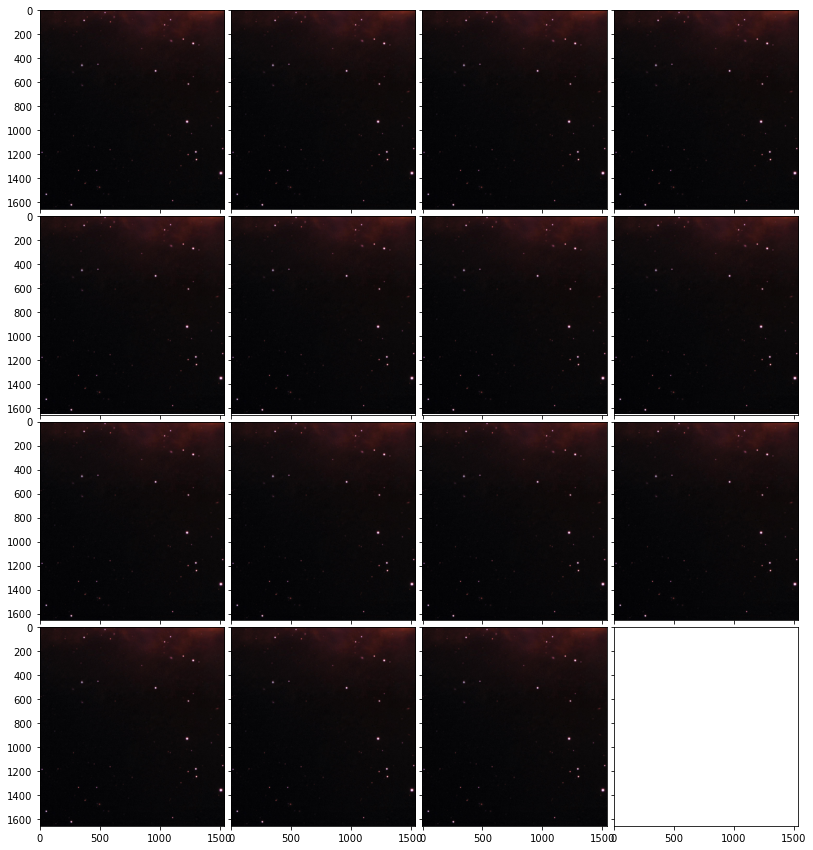

In [90]:
fig = plt.figure(figsize=(15., 15.))
grid = ImageGrid(fig, 111, 
                 nrows_ncols=(4,4),
                 axes_pad=0.1)

for ax, im in zip(grid, range(15)):
    ax.imshow(train_image.astype(np.uint8))

In [84]:
train_image.shape

(6623, 6145, 3)

In [91]:
data = img

In [98]:
whiteintensitythreshold = 1
numwhitethreshold = 70
interestingregions = pd.DataFrame([(i, j, numwhite) for i, j, numwhite in 
           ((i,j, np.sum(data[0, i:(i+30), j:(j+31)]>whiteintensitythreshold)) 
              for i in range(data.shape[1]-30) for j in range(data.shape[2]-31)) if numwhite>numwhitethreshold], 
                                  columns=["i","j", "numwhite"])

In [104]:
from sklearn.cluster import OPTICS
clustering = OPTICS(min_samples=10).fit(interestingregions[["i", "j"]])
print(set(clustering.labels_))
interestingregions["clusid"] = clustering.labels_

In [69]:
z=Image2(DATA_PATH+'sample_1.jpg')

In [ ]:
img_dir = Path(DATA_PATH).glob(EXT)
for img in img_dir:
    grid = ImageGrid(img
